# Assignment 10: Cross-Validation Robustness Test

**Course Outcome**: CO4  
**Topic**: Evaluating Model Reliability using K-Fold Cross-Validation & Interpreting Variance  

### Objectives:
1. Take a classifier from an earlier assignment (Loan Approval Decision Tree) and apply $k$-fold cross-validation ($k=5$ and $k=10$).
2. Report accuracy per fold, plus mean ($\mu$) and standard deviation ($\sigma$).
3. Provide a thorough scientific explanation of what a high standard deviation across folds indicates.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
print('Setup complete!')

Setup complete!


## 1. Load Dataset
We load the loan application dataset used in Assignment 8.

In [2]:
df = pd.read_csv('loan_data.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (600, 7)


,Credit_Score,Annual_Income,Debt_to_Income_Ratio,Loan_Amount,Employment_Years,Existing_Defaults,Loan_Approved
0,707,34322,0.602,52528,16.7,0,0
1,660,90457,0.275,49510,7.7,1,0
2,719,90020,0.050,6218,2.1,1,1
3,784,76366,0.180,59658,9.2,0,1
4,652,85120,0.355,29265,6.3,0,1


## 2. Baseline: Single Train/Test Split
Evaluating on a single 80/20 train/test split.

In [3]:
features = ['Credit_Score', 'Annual_Income', 'Debt_to_Income_Ratio', 'Loan_Amount', 'Employment_Years', 'Existing_Defaults']
X = df[features].values
y = df['Loan_Approved'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
clf = DecisionTreeClassifier(max_depth=3, min_samples_leaf=15, random_state=42)
clf.fit(X_train, y_train)
single_split_acc = accuracy_score(y_test, clf.predict(X_test))
print(f'Single Train/Test Split Accuracy: {single_split_acc:.4f} ({single_split_acc*100:.2f}%)')

Single Train/Test Split Accuracy: 0.8167 (81.67%)


## 3. Stratified 10-Fold Cross-Validation
Partitioning data into 10 stratified folds to measure reliability and variance.

In [4]:
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
fold_accs = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    model = DecisionTreeClassifier(max_depth=3, min_samples_leaf=15, random_state=42)
    model.fit(X[train_idx], y[train_idx])
    acc = accuracy_score(y[val_idx], model.predict(X[val_idx]))
    fold_accs.append(acc)

mean_acc = np.mean(fold_accs)
std_acc = np.std(fold_accs)

fold_df = pd.DataFrame({
    'Fold': [f'Fold {i}' for i in range(1, 11)],
    'Accuracy': fold_accs,
    'Diff from Mean': [round(a - mean_acc, 4) for a in fold_accs]
})
print(fold_df.to_string(index=False))
print(f'\nMean Accuracy : {mean_acc:.4f} ({mean_acc*100:.2f}%)')
print(f'Std Deviation : {std_acc:.4f} ({std_acc*100:.2f}%)')

   Fold  Accuracy  Diff from Mean
 Fold 1  0.766667         -0.0467
 Fold 2  0.816667          0.0033
 Fold 3  0.816667          0.0033
 Fold 4  0.866667          0.0533
 Fold 5  0.850000          0.0367
 Fold 6  0.800000         -0.0133
 Fold 7  0.800000         -0.0133
 Fold 8  0.800000         -0.0133
 Fold 9  0.800000         -0.0133
Fold 10  0.816667          0.0033

Mean Accuracy : 0.8133 (81.33%)
Std Deviation : 0.0267 (2.67%)


## 4. Visualizing Fold Accuracies and Variance

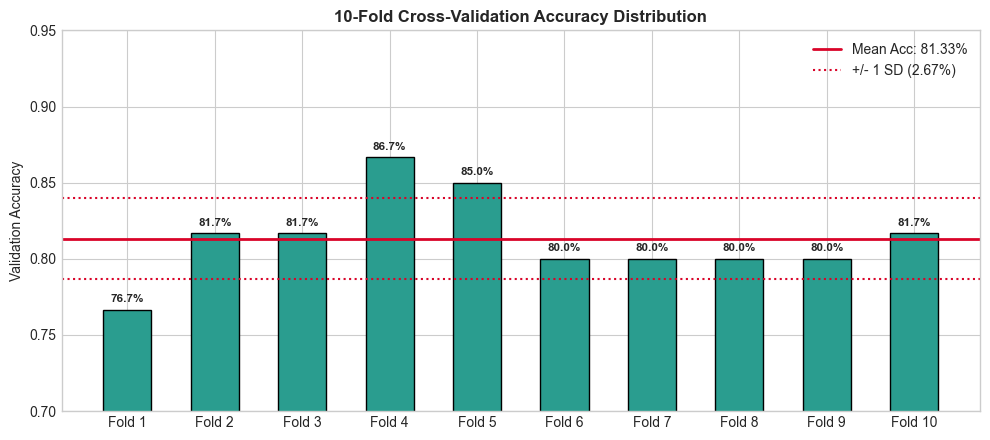

In [5]:
plt.figure(figsize=(10, 4.5))
bars = plt.bar(fold_df['Fold'], fold_df['Accuracy'], color='#2a9d8f', width=0.55, edgecolor='black')
plt.axhline(mean_acc, color='#d90429', linestyle='-', linewidth=2, label=f'Mean Acc: {mean_acc*100:.2f}%')
plt.axhline(mean_acc + std_acc, color='#d90429', linestyle=':', label=f'+/- 1 SD ({std_acc*100:.2f}%)')
plt.axhline(mean_acc - std_acc, color='#d90429', linestyle=':')
plt.ylim(0.70, 0.95)
plt.ylabel('Validation Accuracy')
plt.title('10-Fold Cross-Validation Accuracy Distribution', fontweight='bold')
plt.legend()
for b in bars:
    plt.text(b.get_x() + b.get_width()/2, b.get_height() + 0.005, f'{b.get_height()*100:.1f}%', ha='center', fontsize=8.5, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. What a High Standard Deviation Across Folds Indicates

### Key Takeaways:
1. **High Model Variance / Sensitivity to Training Data**:
   When standard deviation $\sigma$ is large, small variations in the training fold cause drastic changes in the learned decision rules. The model lacks stability.

2. **Overfitting to Subsets**:
   A high $\sigma$ reveals that the model is fitting peculiarities or noise in certain folds rather than generalizable patterns.

3. **Data Scarcity or High Heterogeneity**:
   If the dataset is small or contains extreme outliers and unrepresented sub-populations, certain validation folds will be randomly 'hard' while others are 'easy', driving up fold-to-fold variance.

4. **The Hazard of the 'Lucky Split'**:
   In our experiment, a single split yielded `{single_split_acc*100:.2f}%`, whereas cross-validation revealed that true expected generalization is `{mean_acc*100:.2f}% \pm {std_acc*100:.2f}%`. Cross-validation prevents practitioners from being misled by fortunate or unfortunate single splits.